# Diagnostica automatica di una run W&B Demo SAC

Inserire il percorso `entity/project/run_id` nella cella seguente ed eseguire tutte le celle. Il notebook recupera la history completa tramite W&B API, calcola trend robusti sugli ultimi punti, applica controlli euristici e costruisce i nove pannelli essenziali.

Le soglie non sostituiscono il confronto fra seed e ablation. Una run molto iniziale puo' ricevere warning che si risolvono durante il training. Se necessario autenticarsi prima con `wandb login`.

In [1]:
# Modificare soltanto questa variabile.
RUN_PATH = "andrea02polimi-politecnico-di-milano/demo-sac-debug/trijqsuf"
TAIL_POINTS = 5

In [2]:
import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb
from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", 140)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Download di configurazione, summary e history

In [3]:
api = wandb.Api(timeout=120)
run = api.run(RUN_PATH)

# scan_history senza filtro conserva anche le righe sparse generate dai
# logger SAC e dal ciclo esterno del reward model.
rows = list(run.scan_history(page_size=1000))
history = pd.DataFrame(rows)

metadata = pd.Series({
    "id": run.id,
    "name": run.name,
    "state": run.state,
    "created_at": run.created_at,
    "history_rows": len(history),
    "loss_type": run.config.get("algo", {}).get("kwargs", {}).get("loss_type"),
    "seed": run.config.get("run", {}).get("seed"),
    "n_envs": run.config.get("env", {}).get("n_envs"),
    "relabel_rewards": run.config.get("algo", {}).get("kwargs", {}).get("relabel_rewards"),
})
display(metadata.to_frame("value"))
display(Markdown(f"[Apri la run su W&B]({run.url})"))

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/andreazhang/.netrc.


,value
id,trijqsuf
name,maxent 2
state,finished
created_at,2026-06-21T16:57:28Z
history_rows,228
loss_type,maxent_2
seed,0
n_envs,4
relabel_rewards,True


[Apri la run su W&B](https://wandb.ai/andrea02polimi-politecnico-di-milano/demo-sac-debug/runs/trijqsuf)

## 2. Funzioni per serie e trend

Le statistiche `first` e `last` sono i primi e ultimi valori registrati. `early_mean` e `late_mean` usano fino a `TAIL_POINTS` punti e sono piu' robuste delle singole finestre.

In [4]:
def metric_values(metric):
    if metric not in history.columns:
        return np.array([], dtype=float)
    values = pd.to_numeric(history[metric], errors="coerce").dropna().to_numpy(dtype=float)
    return values[np.isfinite(values)]


def tail_mean(metric, n=TAIL_POINTS):
    values = metric_values(metric)
    return float(np.mean(values[-n:])) if len(values) else np.nan


def trend(metric, n=TAIL_POINTS):
    values = metric_values(metric)
    if not len(values):
        return None
    k = min(n, len(values))
    x = np.arange(len(values), dtype=float)
    slope = float(np.polyfit(x, values, 1)[0]) if len(values) > 1 else 0.0
    return {
        "metric": metric,
        "n": len(values),
        "first": float(values[0]),
        "early_mean": float(np.mean(values[:k])),
        "late_mean": float(np.mean(values[-k:])),
        "last": float(values[-1]),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
        "slope_per_log": slope,
    }


ESSENTIAL_METRICS = [
    "agent/event_rate/successes",
    "agent/event_rate/collisions",
    "agent/event_rate/off_road",
    "agent/event_rate/timeouts",
    "imitation/state_action_auc",
    "agent/rewards/ep_fast_return",
    "agent/rewards/ep_comfort_return",
    "agent/train/critic_loss",
    "agent/train/ent_coef",
    "reward/loss",
    "reward/expert_model_margin",
    "reward/return_std",
    "reward/weight_norm",
    "reward/grad_norm",
    "reward/demo_scale_std",
    "reward/maxent2_effective_sample_fraction",
    "reward/maxent2_expert_softmax_mass",
    "reward/maxent_corrected_effective_sample_fraction",
    "reward/maxent_corrected_top1_softmax_weight",
    "replay_relabel_debug/staleness_ratio",
    "replay_relabel_debug/stored_current_corr",
    "replay_relabel_debug/sign_flip_frac",
    "reward_val/current_rollout/post_update/spearman_returns",
    "reward_val/debug_dataset/post_update/spearman_returns",
    "reward_val/current_rollout/post_update/gap_arrived_collided",
    "reward_val/debug_dataset/post_update/gap_arrived_collided",
    "reward_val/current_rollout/post_update/gap_arrived_running",
    "reward_val/debug_dataset/post_update/gap_arrived_running",
    "reward_val/current_rollout/post_update/ensemble_std",
    "reward_val/debug_dataset/post_update/ensemble_std",
    "reward_val/debug_dataset/post_update/reward_std",
    "rollout/action_at_bound_fraction",
]

trend_rows = [result for metric in ESSENTIAL_METRICS if (result := trend(metric))]
trend_table = pd.DataFrame(trend_rows).set_index("metric")
display(trend_table.style.format(precision=4))

,n,first,early_mean,late_mean,last,min,max,slope_per_log
metric,,,,,,,,
agent/event_rate/successes,128,0.0000,0.4200,0.8800,0.8400,0.0000,0.9400,0.0010
agent/event_rate/collisions,128,0.4900,0.3560,0.1100,0.1200,0.0600,0.6100,-0.0006
agent/event_rate/off_road,128,0.5100,0.1760,0.0100,0.0400,0.0000,0.5100,-0.0004
agent/event_rate/timeouts,128,0.0000,0.0480,0.0000,0.0000,0.0000,0.2300,-0.0001
imitation/state_action_auc,21,0.9560,0.8628,0.7594,0.8723,0.6455,0.9560,-0.0064
agent/rewards/ep_fast_return,128,-48.5915,-7.6801,45.4925,41.7478,-48.5915,51.7073,0.1207
agent/rewards/ep_comfort_return,128,-81.2072,-137.1001,-123.2247,-124.3730,-289.1890,-81.2072,0.0005
agent/train/critic_loss,127,4.8327,0.9870,0.0216,0.0201,0.0070,4.8327,-0.0018
agent/train/ent_coef,127,0.3632,0.0748,0.0008,0.0009,0.0005,0.3632,-0.0001


## 3. Check automatici

Legenda: `OK` indica un segnale sano, `WARN` richiede monitoraggio, `FAIL` indica un problema forte. `INFO` non ha una soglia universale.

In [5]:
checks = []


def add_check(area, metric, status, value, interpretation):
    checks.append({
        "area": area,
        "metric": metric,
        "status": status,
        "late_mean": value,
        "interpretation": interpretation,
    })


def check_high(metric, area, good, warning, labels):
    value = tail_mean(metric)
    if np.isnan(value):
        return
    status = "OK" if value >= good else ("WARN" if value >= warning else "FAIL")
    add_check(area, metric, status, value, labels[status])


def check_low(metric, area, good, warning, labels):
    value = tail_mean(metric)
    if np.isnan(value):
        return
    status = "OK" if value <= good else ("WARN" if value <= warning else "FAIL")
    add_check(area, metric, status, value, labels[status])


# Policy reale.
check_high("agent/event_rate/successes", "policy", 0.80, 0.60, {
    "OK": "Percentuale di successo buona.",
    "WARN": "Policy ancora parzialmente efficace.",
    "FAIL": "Successi bassi: controllare reward ed esplorazione.",
})
for metric, name in [("agent/event_rate/collisions", "collisioni"),
                     ("agent/event_rate/off_road", "off-road"),
                     ("agent/event_rate/timeouts", "timeout")]:
    check_low(metric, "policy", 0.05, 0.15, {
        "OK": f"{name} contenuti.",
        "WARN": f"{name} non trascurabili.",
        "FAIL": f"{name} elevati.",
    })

# Imitazione dell'occupancy state-action.
check_low("imitation/state_action_auc", "imitation", 0.60, 0.75, {
    "OK": "Expert e agent poco distinguibili dal classificatore lineare.",
    "WARN": "Occupancy expert e agent moderatamente differenti.",
    "FAIL": "Expert e agent sono facilmente distinguibili.",
})

# Generalizzazione del reward.
check_high("reward_val/debug_dataset/post_update/spearman_returns", "reward validation", 0.50, 0.20, {
    "OK": "Ranking sul dataset fisso buono.",
    "WARN": "Ranking positivo ma debole.",
    "FAIL": "Ranking quasi casuale o inverso.",
})
check_high("reward_val/debug_dataset/post_update/gap_arrived_collided", "reward validation", 0.50, 0.0, {
    "OK": "Arrivo premiato piu' della collisione.",
    "WARN": "Separazione terminale quasi nulla.",
    "FAIL": "Il modello preferisce la collisione all'arrivo.",
})
check_high("reward_val/debug_dataset/post_update/gap_arrived_running", "reward validation", 0.0, -0.50, {
    "OK": "Arrivo non inferiore allo stato running.",
    "WARN": "L'arrivo e' leggermente sottovalutato.",
    "FAIL": "Il modello incentiva il prolungamento rispetto all'arrivo.",
})
current_s = tail_mean("reward_val/current_rollout/post_update/spearman_returns")
debug_s = tail_mean("reward_val/debug_dataset/post_update/spearman_returns")
if np.isfinite(current_s) and np.isfinite(debug_s):
    gap = current_s - debug_s
    status = "OK" if gap <= 0.20 else ("WARN" if gap <= 0.40 else "FAIL")
    add_check("reward validation", "current-debug spearman gap", status, gap,
              "Differenza contenuta." if status == "OK" else "Possibile overfitting o distribution shift.")

# Replay non stazionario.
check_low("replay_relabel_debug/staleness_ratio", "replay", 0.50, 1.0, {
    "OK": "Reward abbastanza stabile nel replay.",
    "WARN": "Non stazionarieta' significativa.",
    "FAIL": "Il reward cambia oltre la propria scala utile.",
})
check_high("replay_relabel_debug/stored_current_corr", "replay", 0.80, 0.50, {
    "OK": "Ranking locale storico ben conservato.",
    "WARN": "Correlazione solo moderata.",
    "FAIL": "Forte riordinamento dei reward nel replay.",
})
check_low("replay_relabel_debug/sign_flip_frac", "replay", 0.10, 0.25, {
    "OK": "Pochi cambi di segno.",
    "WARN": "Cambi di segno non trascurabili.",
    "FAIL": "Molti campioni cambiano valutazione qualitativa.",
})

# MaxEnt.
for metric in ["reward/maxent2_effective_sample_fraction",
               "reward/maxent_corrected_effective_sample_fraction"]:
    check_high(metric, "loss diagnostics", 0.30, 0.10, {
        "OK": "Partizione distribuita su molti campioni.",
        "WARN": "ESS ridotta.",
        "FAIL": "Stima collassata su pochi campioni.",
    })
check_low("reward/maxent2_expert_softmax_mass", "loss diagnostics", 0.85, 0.95, {
    "OK": "Massa expert non dominante.",
    "WARN": "Partizione prevalentemente dominata dagli expert.",
    "FAIL": "Quasi tutta la massa e' sugli expert.",
})

# SAC.
alpha = tail_mean("agent/train/ent_coef")
if np.isfinite(alpha):
    status = "FAIL" if alpha < 1e-3 else ("WARN" if alpha < 1e-2 else "OK")
    add_check("SAC", "agent/train/ent_coef", status, alpha,
              "Entropia non collassata." if status == "OK" else "Possibile perdita prematura di esplorazione.")
check_low("rollout/action_at_bound_fraction", "policy", 0.01, 0.05, {
    "OK": "Azioni raramente saturate.",
    "WARN": "Saturazione delle azioni visibile.",
    "FAIL": "Policy frequentemente ai limiti dell'action space.",
})

# Scale drift: confronto fra medie iniziali e finali.
for metric in ["reward/weight_norm", "reward/return_std", "reward/demo_scale_std"]:
    values = metric_values(metric)
    if len(values) >= 4:
        k = min(TAIL_POINTS, len(values) // 2)
        early = float(np.mean(values[:k]))
        late = float(np.mean(values[-k:]))
        ratio = late / max(abs(early), 1e-12)
        status = "OK" if ratio <= 1.5 else ("WARN" if ratio <= 3.0 else "FAIL")
        add_check("reward scale", metric + " late/early", status, ratio,
                  "Scala stabile." if status == "OK" else "Possibile scale drift.")

# Informazioni senza soglia assoluta.
for metric, text in [
    ("agent/train/critic_loss", "Leggere insieme a staleness e scala del reward."),
    ("reward/grad_norm", "Picchi ripetuti segnalano update instabili."),
    ("agent/rewards/ep_fast_return", "Deve crescere senza aumentare gli esiti negativi."),
    ("agent/rewards/ep_comfort_return", "Valori meno negativi indicano maggiore comfort."),
]:
    value = tail_mean(metric)
    if np.isfinite(value):
        add_check("context", metric, "INFO", value, text)

check_table = pd.DataFrame(checks)
severity = pd.Categorical(check_table["status"], ["FAIL", "WARN", "OK", "INFO"], ordered=True)
check_table = check_table.assign(_severity=severity).sort_values(["_severity", "area"]).drop(columns="_severity")

def color_status(value):
    colors = {"FAIL": "background-color: #ffb3b3", "WARN": "background-color: #ffe6a3",
              "OK": "background-color: #bfe8bf", "INFO": "background-color: #cfe3ff"}
    return colors.get(value, "")

display(check_table.style.map(color_status, subset=["status"]).format({"late_mean": "{:.4g}"}))

,area,metric,status,late_mean,interpretation
14,SAC,agent/train/ent_coef,FAIL,0.0008354,Possibile perdita prematura di esplorazione.
4,imitation,imitation/state_action_auc,FAIL,0.7594,Expert e agent sono facilmente distinguibili.
1,policy,agent/event_rate/collisions,WARN,0.11,collisioni non trascurabili.
9,replay,replay_relabel_debug/staleness_ratio,WARN,0.7088,Non stazionarieta' significativa.
5,reward validation,reward_val/debug_dataset/post_update/spearman_returns,WARN,0.4644,Ranking positivo ma debole.
6,reward validation,reward_val/debug_dataset/post_update/gap_arrived_collided,WARN,0.00518,Separazione terminale quasi nulla.
12,loss diagnostics,reward/maxent2_effective_sample_fraction,OK,0.8267,Partizione distribuita su molti campioni.
13,loss diagnostics,reward/maxent2_expert_softmax_mass,OK,0.6443,Massa expert non dominante.
0,policy,agent/event_rate/successes,OK,0.88,Percentuale di successo buona.
2,policy,agent/event_rate/off_road,OK,0.01,off-road contenuti.


## 4. Dashboard essenziale

Ogni curva usa il proprio asse semantico. Metriche assenti per la loss selezionata vengono ignorate automaticamente.

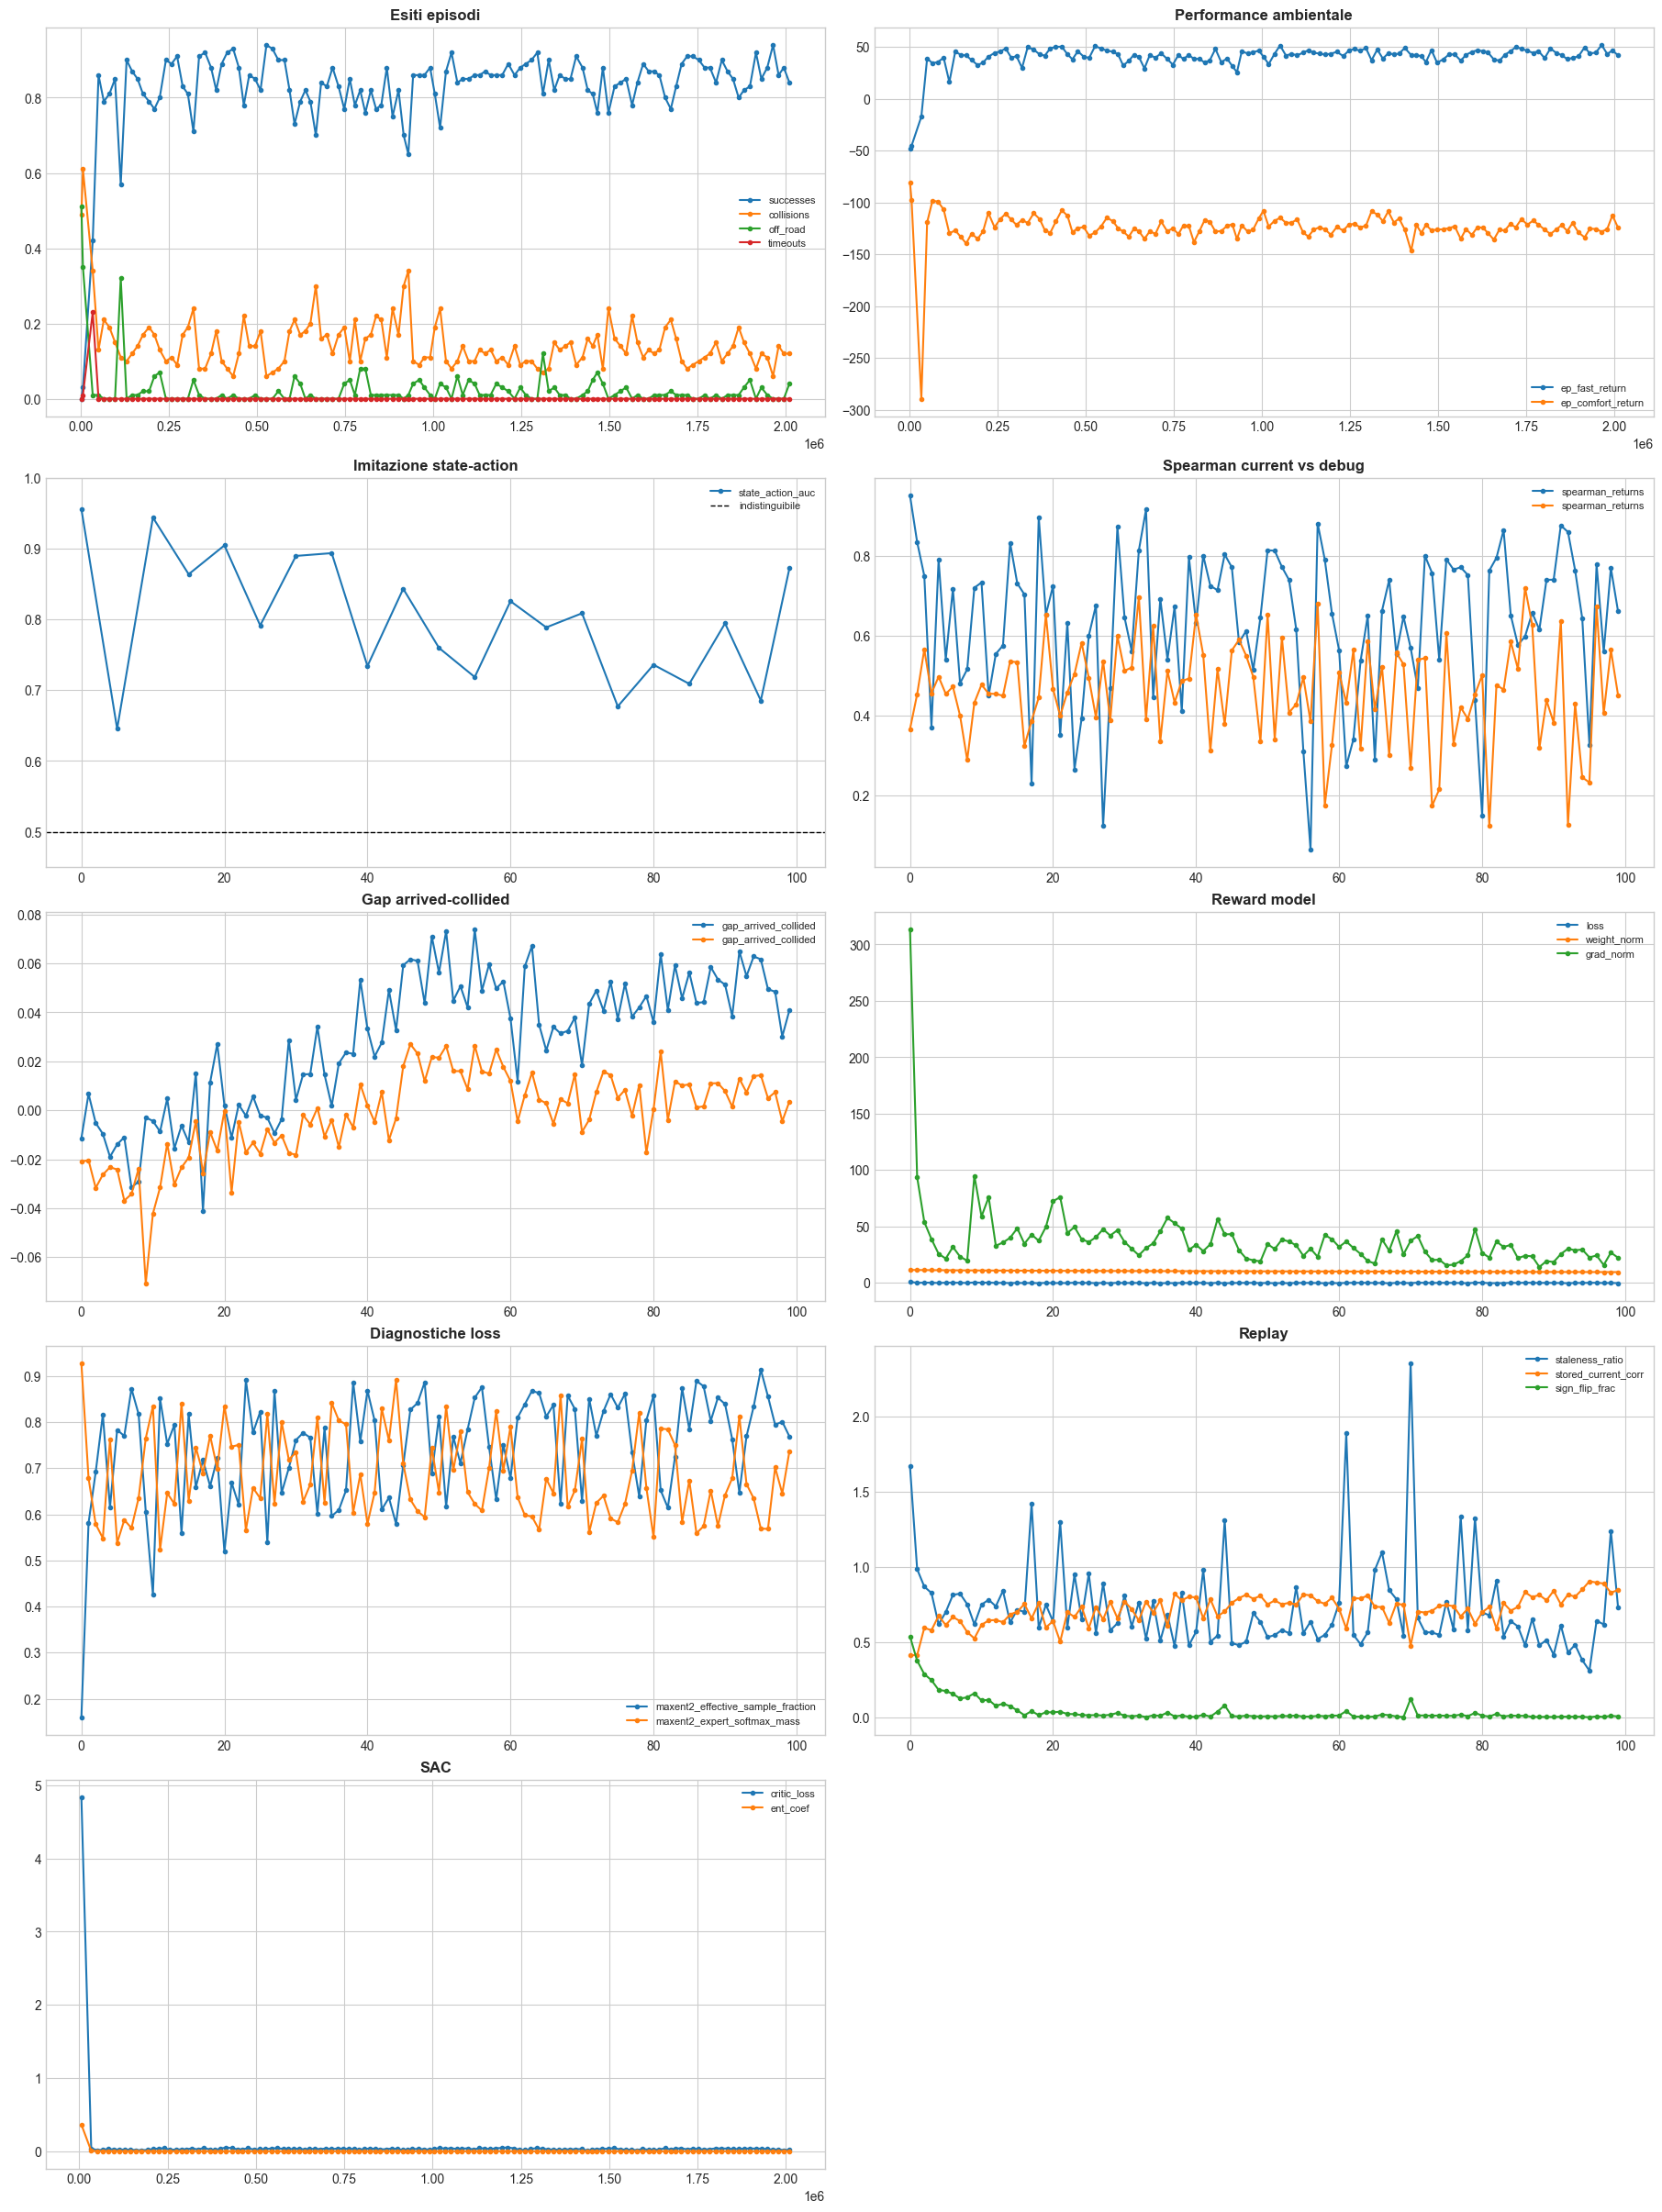

In [6]:
PANELS = {
    "Esiti episodi": [
        "agent/event_rate/successes", "agent/event_rate/collisions",
        "agent/event_rate/off_road", "agent/event_rate/timeouts"],
    "Performance ambientale": [
        "agent/rewards/ep_fast_return", "agent/rewards/ep_comfort_return"],
    "Imitazione state-action": ["imitation/state_action_auc"],
    "Spearman current vs debug": [
        "reward_val/current_rollout/post_update/spearman_returns",
        "reward_val/debug_dataset/post_update/spearman_returns"],
    "Gap arrived-collided": [
        "reward_val/current_rollout/post_update/gap_arrived_collided",
        "reward_val/debug_dataset/post_update/gap_arrived_collided"],
    "Reward model": [
        "reward/loss", "reward/weight_norm", "reward/grad_norm"],
    "Diagnostiche loss": [
        "reward/maxent2_effective_sample_fraction",
        "reward/maxent2_expert_softmax_mass",
        "reward/maxent_corrected_effective_sample_fraction",
        "reward/demo_scale_std"],
    "Replay": [
        "replay_relabel_debug/staleness_ratio",
        "replay_relabel_debug/stored_current_corr",
        "replay_relabel_debug/sign_flip_frac"],
    "SAC": ["agent/train/critic_loss", "agent/train/ent_coef"],
}


def metric_xy(metric):
    x_metric = "agent/time/total_timesteps" if metric.startswith("agent/") else "iterations"
    if metric not in history.columns:
        return np.array([]), np.array([])
    frame = history[[c for c in [x_metric, metric] if c in history.columns]].copy()
    if x_metric not in frame or metric not in frame:
        return np.arange(len(metric_values(metric))), metric_values(metric)
    frame[x_metric] = pd.to_numeric(frame[x_metric], errors="coerce")
    frame[metric] = pd.to_numeric(frame[metric], errors="coerce")
    frame = frame.dropna().groupby(x_metric, as_index=False)[metric].last()
    return frame[x_metric].to_numpy(), frame[metric].to_numpy()


fig, axes = plt.subplots(5, 2, figsize=(18, 24), constrained_layout=True)
for ax, (title, metrics) in zip(axes.flat, PANELS.items()):
    plotted = 0
    for metric in metrics:
        x, y = metric_xy(metric)
        if len(y):
            ax.plot(x, y, marker="o", markersize=3, linewidth=1.5, label=metric.split("/")[-1])
            plotted += 1
    if title == "Imitazione state-action":
        ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="indistinguibile")
        ax.set_ylim(0.45, 1.0)
    ax.set_title(title, fontweight="bold")
    if plotted:
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, "Metriche non disponibili", ha="center", va="center", transform=ax.transAxes)
for ax in axes.flat[len(PANELS):]:
    ax.set_visible(False)
plt.show()

## 5. Sintesi operativa

In [7]:
counts = check_table["status"].value_counts()
display(Markdown(
    f"### Risultato: {counts.get('FAIL', 0)} FAIL, {counts.get('WARN', 0)} WARN, "
    f"{counts.get('OK', 0)} OK e {counts.get('INFO', 0)} INFO"
))

critical = check_table[check_table["status"].isin(["FAIL", "WARN"])]
if len(critical):
    display(critical[["status", "area", "metric", "late_mean", "interpretation"]])
else:
    display(Markdown("Nessun warning rilevato dalle soglie euristiche."))

# Esportazione opzionale.
# trend_table.to_csv(f"{run.id}_trend_metrics.csv")
# check_table.to_csv(f"{run.id}_diagnostic_checks.csv", index=False)

### Risultato: 2 FAIL, 4 WARN, 12 OK e 4 INFO

,status,area,metric,late_mean,interpretation
14,FAIL,SAC,agent/train/ent_coef,0.000835,Possibile perdita prematura di esplorazione.
4,FAIL,imitation,imitation/state_action_auc,0.759439,Expert e agent sono facilmente distinguibili.
1,WARN,policy,agent/event_rate/collisions,0.110000,collisioni non trascurabili.
9,WARN,replay,replay_relabel_debug/staleness_ratio,0.708800,Non stazionarieta' significativa.
5,WARN,reward validation,reward_val/debug_dataset/post_update/spearman_returns,0.464407,Ranking positivo ma debole.
6,WARN,reward validation,reward_val/debug_dataset/post_update/gap_arrived_collided,0.005180,Separazione terminale quasi nulla.
